In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from numpy.random import seed
from sklearn.preprocessing import minmax_scale
from sklearn.model_selection import train_test_split


In [2]:
#from __future__ import print_function
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.callbacks import ModelCheckpoint
#from keras.models import model_from_json
from keras import backend as K
from keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D, Flatten, Reshape,BatchNormalization,Lambda
from keras.models import Model
from keras.optimizers import Adam


/mnt/disks/user/anaconda3/lib/python3.6/site-packages/h5py/__init__.py:36: FutureWarning: Conversion of the second argument of issubdtype from `float` to `np.floating` is deprecated. In future, it will be treated as `np.float64 == np.dtype(float).type`.
  from ._conv import register_converters as _register_converters
Using TensorFlow backend.


In [125]:
inp_file=input("Enter the file name:")

Enter the file name:kdd_train_prep2.csv


In [127]:
hidden_size=int(input("Enter the features dim:"))

Enter the features dim:25


In [128]:
kdd_FE= pd.read_csv(str(inp_file))

In [129]:
kdd_FE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Columns: 116 entries, duration to label_5
dtypes: float64(113), object(3)
memory usage: 111.5+ MB


In [130]:
label_list=[ 'attack','label_2','label_5']
kdd_FE_label=kdd_FE[label_list]
print(kdd_FE_label.head())
print("kdd_FE_label:", kdd_FE_label.shape)

    attack label_2 label_5
0   normal  normal  Normal
1   normal  normal  Normal
2  neptune  attack     DoS
3   normal  normal  Normal
4   normal  normal  Normal
kdd_FE_label: (125973, 3)


In [131]:
kdd_FE.drop(label_list, axis = 1, inplace = True)

In [132]:
# define the number of features
ncol = kdd_FE.shape[1]
print(ncol)

113


#### Split train data into train and validation 70:30 in ratio

In [133]:
X_train, X_val,y_train, y_val = train_test_split(kdd_FE,kdd_FE_label['label_2'], train_size = 0.7, test_size = 0.3, random_state = seed(100))

In [134]:
X_train.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
49245,0.00000,3.333421e-08,5.725464e-08,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
125756,0.27221,5.347966e-07,7.931982e-05,0.0,0.0,0.0,0.0,0.0,1.0,0.05014,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9972,0.00000,2.681230e-08,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
27021,0.00000,1.565258e-07,9.756191e-07,0.0,0.0,0.0,0.0,0.0,1.0,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
28666,0.00000,1.673957e-07,2.549740e-07,0.0,0.0,0.0,0.0,0.0,1.0,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [135]:
y_train.head()

49245     normal
125756    normal
9972      attack
27021     normal
28666     normal
Name: label_2, dtype: object

In [136]:
X_train.shape

(88181, 113)

In [137]:
X_val.shape

(37792, 113)

In [138]:
### Define the encoder dimension
#encoding_dim = 50


In [139]:
input_dim=X_train.shape[1]
latent_dim=2
print("Input Feature: ",input_dim)
print("Reduced to:",hidden_size)

Input Feature:  113
Reduced to: 25


In [140]:
x = Input(shape=(input_dim,))
t = BatchNormalization()(x)

#t =  Dense(64, activation='elu' , name='encoder_layer')(t)
#t =  Dense(32, activation='elu' , name='encoder_layer2')(t)
t = Dense(hidden_size, activation='elu' , name='encoder_hidden')(t)
t = BatchNormalization()(t)

z_mean = Dense(latent_dim, name='z_mean')(t)
z_log_var = Dense(latent_dim, name='z_log_var')(t)

def sampling(args):
    z_mean, z_log_var = args
    epsilon = K.random_normal(shape=K.shape(z_mean), mean=0., stddev=1.)
    return z_mean + K.exp(z_log_var / 2) * epsilon
z = Lambda(sampling, name='z_sampled')([z_mean, z_log_var])
t = BatchNormalization()(z)


t = Dense(hidden_size, activation='elu', name='decoder_hidden')(t)
#t =  Dense(32, activation='elu' , name='decoder_layer1')(t)
#t =  Dense(64, activation='elu' , name='decoder_layer')(t)
t = BatchNormalization()(t)

decoded_mean = Dense(input_dim, activation=None, name='decoded_mean')(t)


def rec_loss(y_true, y_pred):
    return K.sum(K.square(y_true - y_pred), axis=-1)
def kl_loss(y_true, y_pred):
    return - 0.5 * K.sum(1 + z_log_var - K.square(z_mean) - K.exp(z_log_var), axis=-1)

def vae_loss(x, decoded_mean):
    rec_loss = K.sum(K.square(x - decoded_mean), axis=-1)
    kl_loss = - 0.5 * K.sum(1 + z_log_var - K.square(z_mean) - K.exp(z_log_var), axis=-1)
    return K.mean((rec_loss + kl_loss) / 2)

vae = Model(x, decoded_mean)
vae.compile(optimizer=Adam(lr=1e-2), loss=vae_loss, metrics=[rec_loss, kl_loss])
vae.summary()

__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_6 (InputLayer)            (None, 113)          0                                            
__________________________________________________________________________________________________
batch_normalization_21 (BatchNo (None, 113)          452         input_6[0][0]                    
__________________________________________________________________________________________________
encoder_hidden (Dense)          (None, 25)           2850        batch_normalization_21[0][0]     
__________________________________________________________________________________________________
batch_normalization_22 (BatchNo (None, 25)           100         encoder_hidden[0][0]             
__________________________________________________________________________________________________
z_mean (De

### Train Auto Encoder

In [141]:
epochs=15

In [142]:
batch_size=100

In [143]:
#vae = Model(x, decoded_mean)
#vae.compile(optimizer=Adam(lr=1e-2), loss=vae_loss, metrics=[rec_loss, kl_loss])
import time
start_time= time.time()
history=vae.fit(X_train, X_train, epochs = epochs, batch_size = batch_size, shuffle = False, validation_data = (X_val, X_val))
print("\n\nRun Time ->","--- %s seconds ---" % (time.time() - start_time))


Train on 88181 samples, validate on 37792 samples
Epoch 1/15
88181/88181 [==============================] - 13s 144us/step - loss: 1.6113 - rec_loss: 2.7448 - kl_loss: 0.4779 - val_loss: 1.4799 - val_rec_loss: 2.3741 - val_kl_loss: 0.5857
Epoch 2/15
88181/88181 [==============================] - 11s 121us/step - loss: 1.4455 - rec_loss: 2.3487 - kl_loss: 0.5424 - val_loss: 1.4395 - val_rec_loss: 2.2656 - val_kl_loss: 0.6135
Epoch 3/15
88181/88181 [==============================] - 11s 121us/step - loss: 1.4273 - rec_loss: 2.2643 - kl_loss: 0.5904 - val_loss: 1.4203 - val_rec_loss: 2.1953 - val_kl_loss: 0.6453
Epoch 4/15
88181/88181 [==============================] - 11s 121us/step - loss: 1.4212 - rec_loss: 2.2189 - kl_loss: 0.6235 - val_loss: 1.4108 - val_rec_loss: 2.1829 - val_kl_loss: 0.6388
Epoch 5/15
88181/88181 [==============================] - 11s 120us/step - loss: 1.4184 - rec_loss: 2.1965 - kl_loss: 0.6402 - val_loss: 1.4189 - val_rec_loss: 2.2183 - val_kl_loss: 0.6194
Epoch

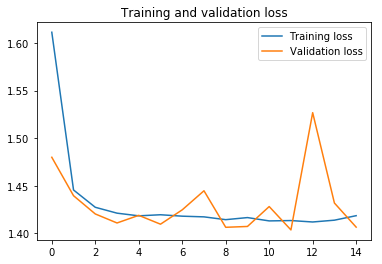

In [144]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(15)
plt.figure()
plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

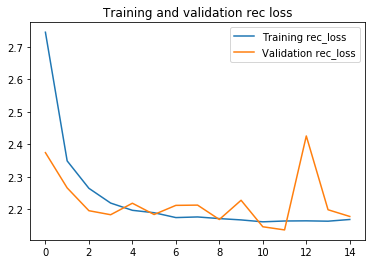

In [145]:
loss = history.history['rec_loss']
val_loss = history.history['val_rec_loss']
epochs = range(15)
plt.figure()
plt.plot(epochs, loss, label='Training rec_loss')
plt.plot(epochs, val_loss, label='Validation rec_loss')
plt.title('Training and validation rec loss')
plt.legend()
plt.show()

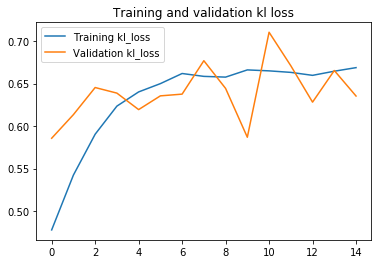

In [146]:
loss = history.history['kl_loss']
val_loss = history.history['val_kl_loss']
epochs = range(15)
plt.figure()
plt.plot(epochs, loss, label='Training kl_loss')
plt.plot(epochs, val_loss, label='Validation kl_loss')
plt.title('Training and validation kl loss')
plt.legend()
plt.show()

### Use Encoder level to reduce dimension of train and test data

In [147]:
encoder = Model(x, z_mean)

### Predict the new train and test data using Encoder

In [148]:
import time
start_time= time.time()
encoded_df = pd.DataFrame(encoder.predict(kdd_FE))
encoded_df = encoded_df.add_prefix('feature_')
print("\n\nRun Time ->","--- %s seconds ---" % (time.time() - start_time))

#encoded_test = pd.DataFrame(encoder.predict(X_test))
#encoded_test = encoded_test.add_prefix('feature_')



Run Time -> --- 6.3686113357543945 seconds ---


In [124]:
encoded_df = pd.concat([encoded_df,kdd_FE_label], axis = 1)
encoded_df.head()

,feature_0,feature_1,attack,label_2,label_5
0,-1.423798,-0.000432,neptune,attack,DoS
1,-1.405952,0.002046,neptune,attack,DoS
2,0.140238,-0.002097,normal,normal,Normal
3,0.079915,-0.014660,saint,attack,Probe
4,-0.392928,-0.017682,mscan,attack,Probe


In [172]:
encoded_df.shape

(22544, 5)

In [173]:
encoded_df.head()

,feature_0,feature_1,attack,label_2,label_5
0,1.575795,0.070001,neptune,attack,DoS
1,1.588168,0.073355,neptune,attack,DoS
2,-0.042037,0.176597,normal,normal,Normal
3,-0.049919,0.358898,saint,attack,Probe
4,0.885184,0.570391,mscan,attack,Probe


In [174]:
out_file=inp_file.split(".")[0] + "_VAE.csv"

In [175]:
encoded_df.to_csv(out_file,index=False)